In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Library berhasil di-load.")

Library berhasil di-load.


In [3]:
df = pd.read_csv("ai4i2020.csv")

print("Dataset berhasil dibaca.")
print("Ukuran dataset:", df.shape)

display(df.head())

Dataset berhasil dibaca.
Ukuran dataset: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Nama kolom:")

for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

Nama kolom:
1. UDI
2. Product ID
3. Type
4. Air temperature [K]
5. Process temperature [K]
6. Rotational speed [rpm]
7. Torque [Nm]
8. Tool wear [min]
9. Machine failure
10. TWF
11. HDF
12. PWF
13. OSF
14. RNF


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [7]:
missing = pd.DataFrame({
    "Jumlah Missing": df.isnull().sum(),
    "Persentase (%)": df.isnull().mean() * 100
})

display(missing)

,Jumlah Missing,Persentase (%)
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


In [8]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [9]:
print(df["Type"].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


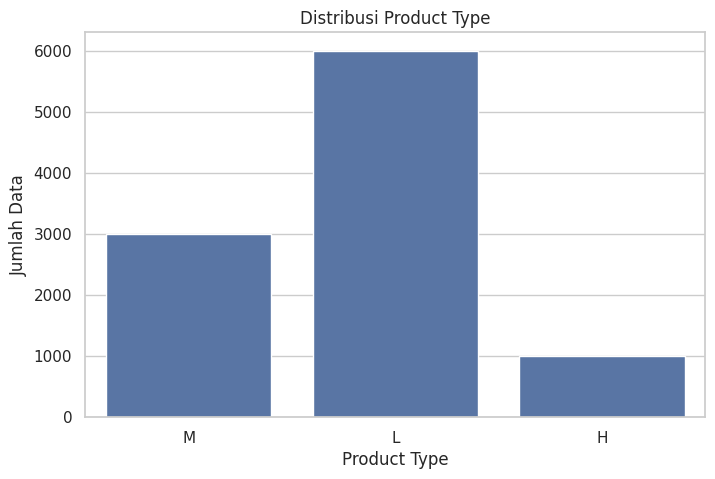

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Type"
)

plt.title("Distribusi Product Type")
plt.xlabel("Product Type")
plt.ylabel("Jumlah Data")

plt.show()

In [11]:
print(df["Machine failure"].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


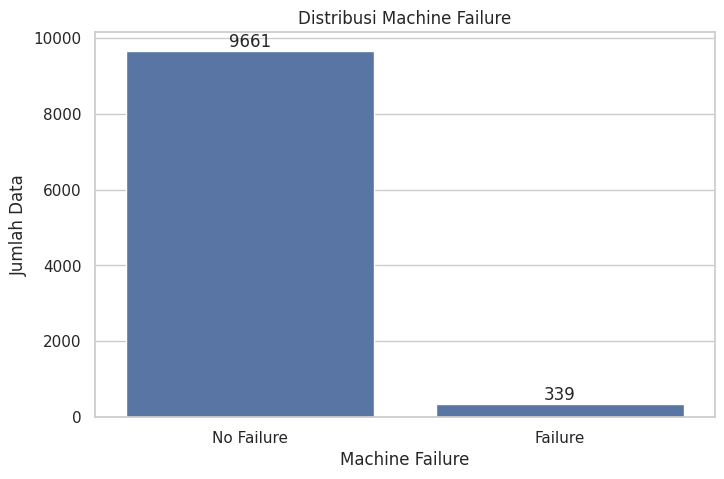

In [12]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title("Distribusi Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Jumlah Data")

plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [13]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

print(features)

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


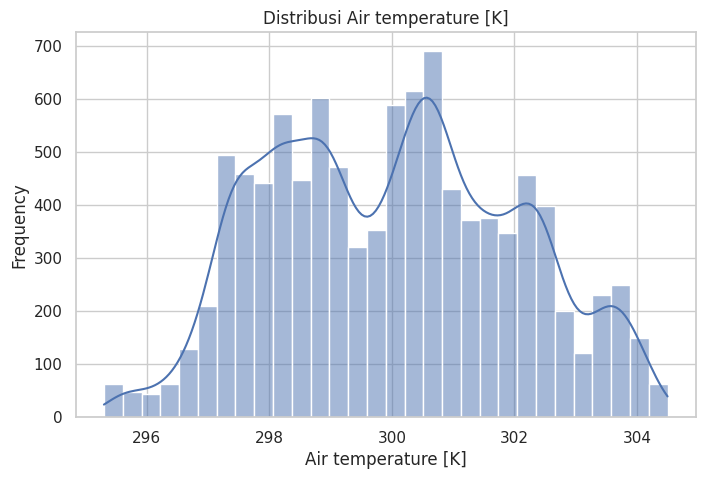

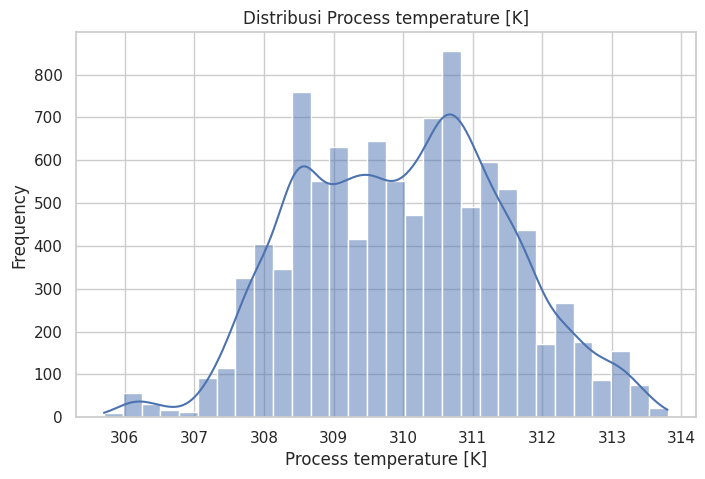

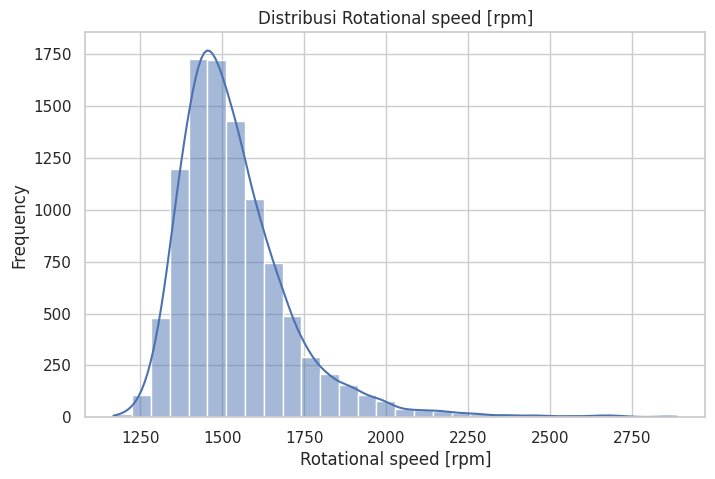

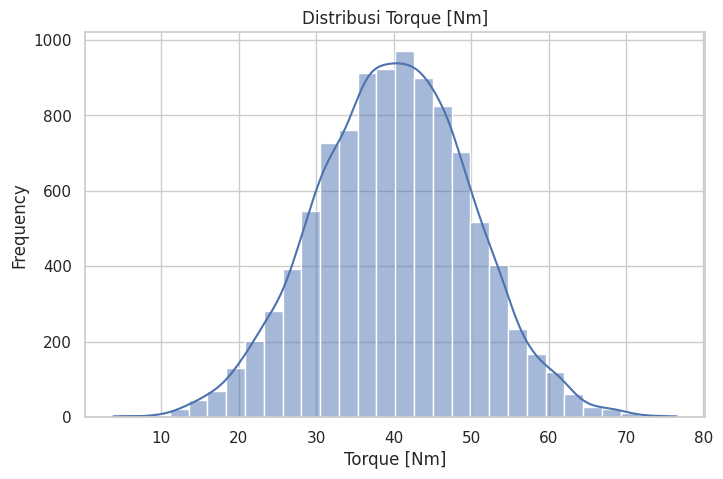

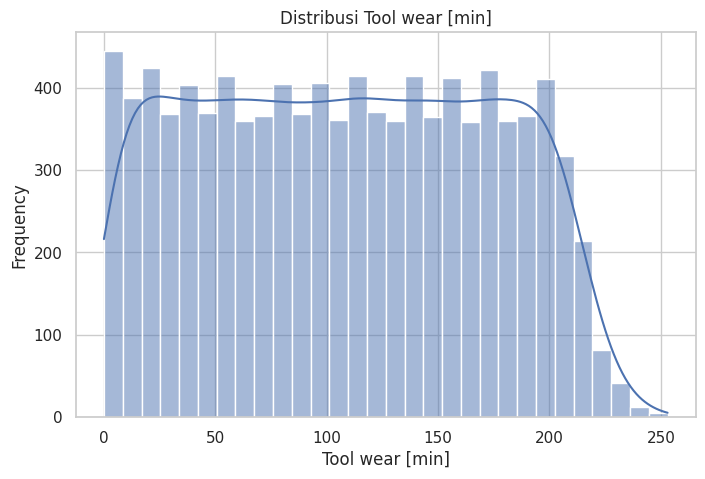

In [14]:
for col in features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )

    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

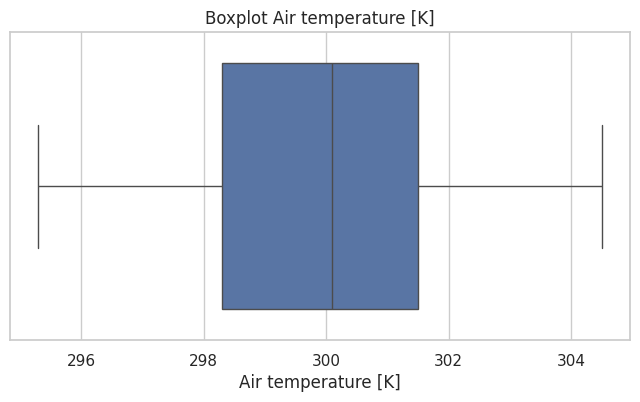

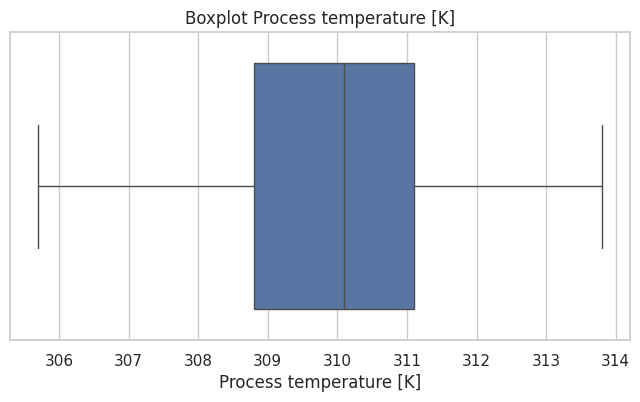

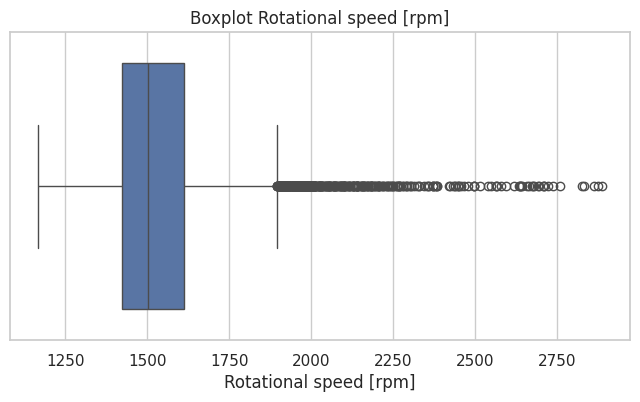

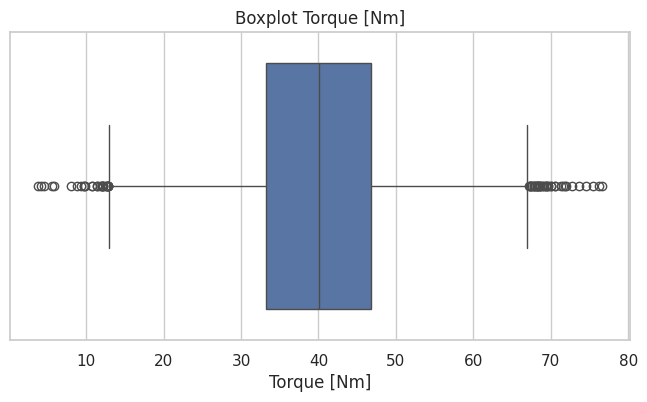

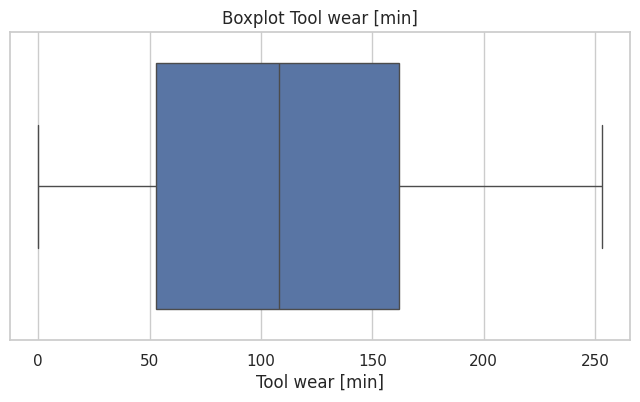

In [15]:
for col in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot {col}")

    plt.show()

In [16]:
outlier_summary = []

for col in features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    outlier_summary.append({
        "Feature": col,
        "Jumlah Outlier": len(outliers),
        "Persentase": len(outliers) / len(df) * 100
    })

display(pd.DataFrame(outlier_summary))

,Feature,Jumlah Outlier,Persentase
0,Air temperature [K],0,0.00
1,Process temperature [K],0,0.00
2,Rotational speed [rpm],418,4.18
3,Torque [Nm],69,0.69
4,Tool wear [min],0,0.00


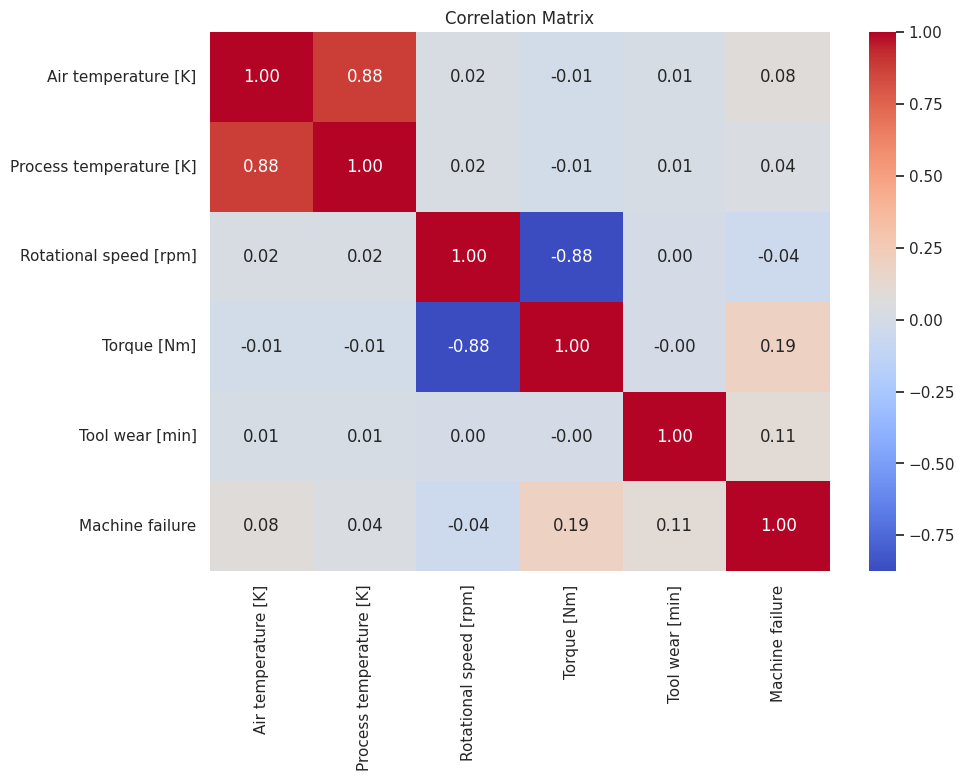

In [17]:
correlation_columns = features + ["Machine failure"]

corr = df[correlation_columns].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [18]:
print("Korelasi terhadap Machine Failure:")

display(
    corr["Machine failure"]
    .sort_values(ascending=False)
)

Korelasi terhadap Machine Failure:


,Machine failure
Machine failure,1.000000
Torque [Nm],0.191321
Tool wear [min],0.105448
Air temperature [K],0.082556
Process temperature [K],0.035946
Rotational speed [rpm],-0.044188


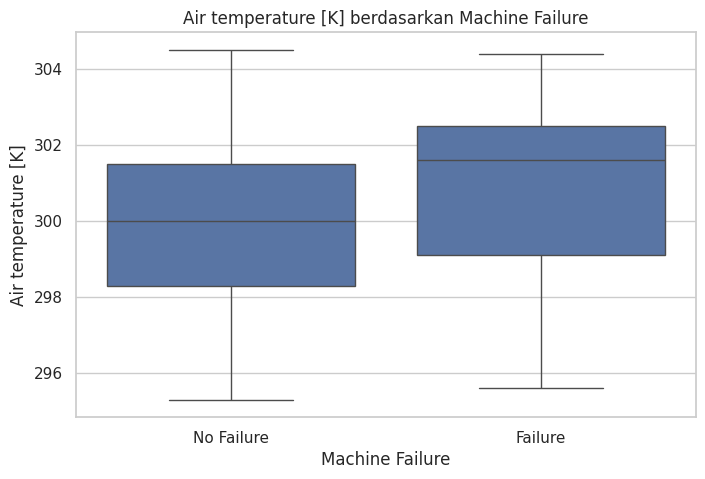

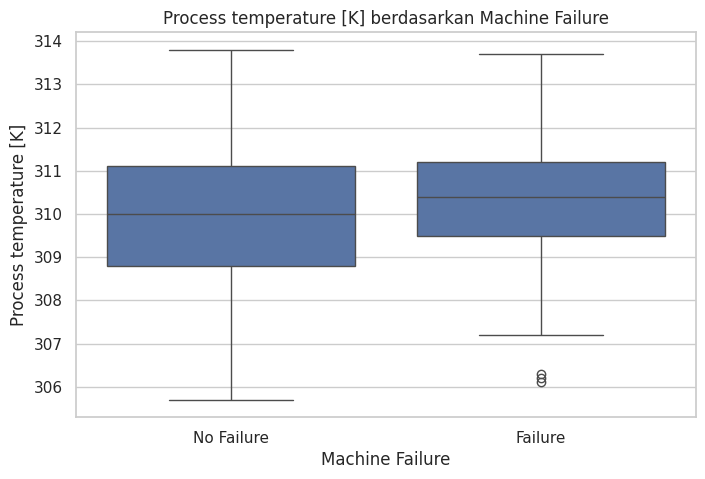

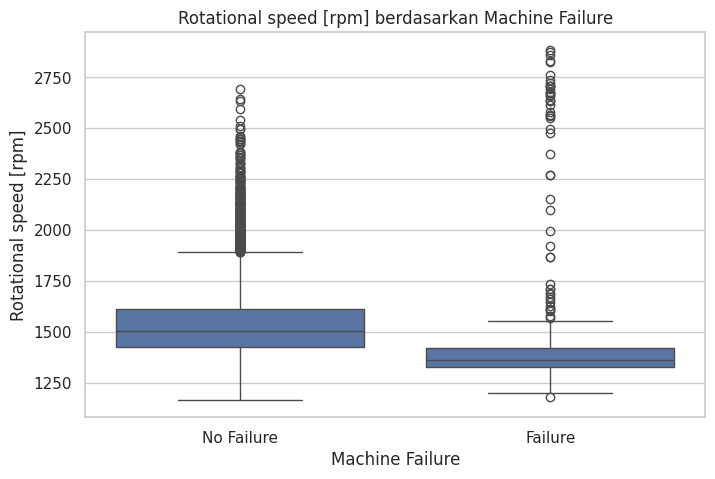

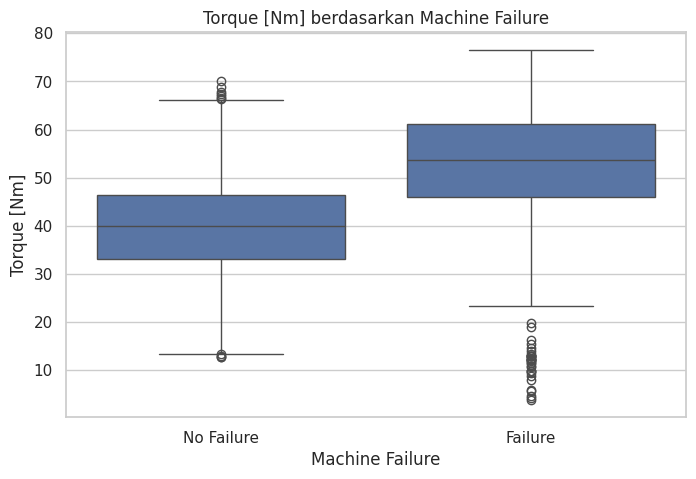

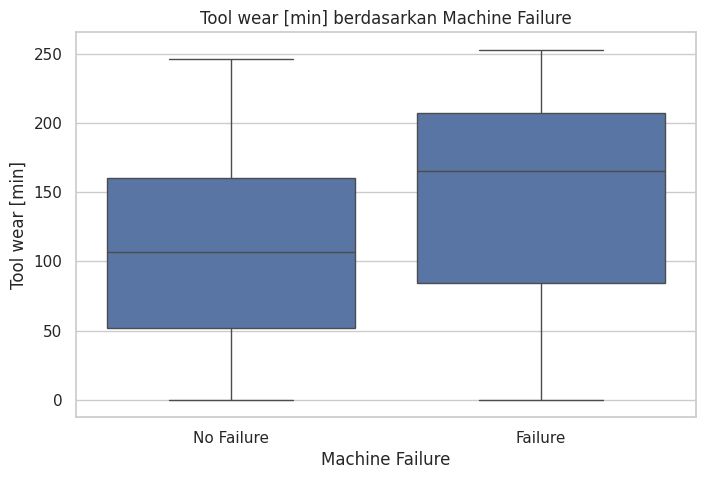

In [19]:
for col in features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=col
    )

    plt.title(
        f"{col} berdasarkan Machine Failure"
    )

    plt.xlabel("Machine Failure")
    plt.ylabel(col)

    plt.xticks(
        [0,1],
        ["No Failure", "Failure"]
    )

    plt.show()

In [20]:
df["Tool wear group"] = pd.cut(
    df["Tool wear [min]"],
    bins=[-1, 50, 100, 150, 200, 253],
    labels=[
        "0-50",
        "51-100",
        "101-150",
        "151-200",
        "201-253"
    ]
)

In [21]:
tool_failure = (
    df.groupby(
        "Tool wear group",
        observed=False
    )["Machine failure"]
    .agg(["count", "sum", "mean"])
)

tool_failure["failure_percentage"] = (
    tool_failure["mean"] * 100
)

display(tool_failure)

,count,sum,mean,failure_percentage
Tool wear group,,,,
0-50,2396,52,0.021703,2.170284
51-100,2271,53,0.023338,2.333774
101-150,2295,50,0.021786,2.178649
151-200,2276,66,0.028998,2.899824
201-253,762,118,0.154856,15.485564


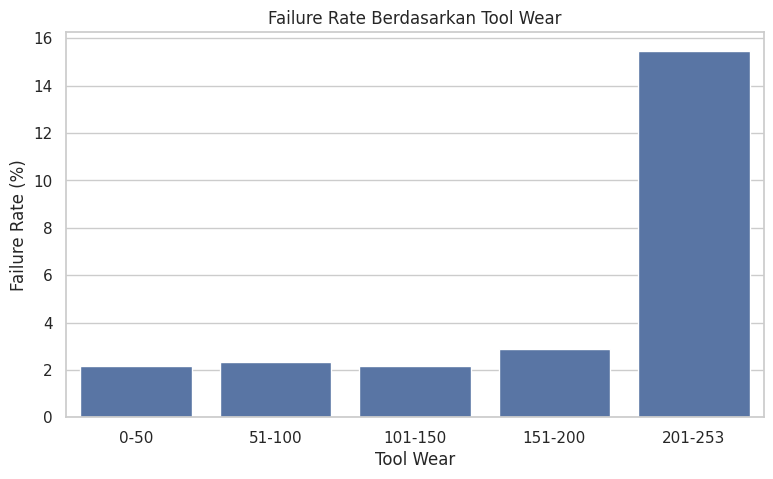

In [22]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=tool_failure.reset_index(),
    x="Tool wear group",
    y="failure_percentage"
)

plt.title("Failure Rate Berdasarkan Tool Wear")
plt.xlabel("Tool Wear")
plt.ylabel("Failure Rate (%)")

plt.show()

In [23]:
failure_modes = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

for col in failure_modes:

    print("\n==========================")
    print(col)

    print(
        df[col].value_counts()
    )


TWF
TWF
0    9954
1      46
Name: count, dtype: int64

HDF
HDF
0    9885
1     115
Name: count, dtype: int64

PWF
PWF
0    9905
1      95
Name: count, dtype: int64

OSF
OSF
0    9902
1      98
Name: count, dtype: int64

RNF
RNF
0    9981
1      19
Name: count, dtype: int64


In [24]:
for col in failure_modes:

    table = pd.crosstab(
        df[col],
        df["Machine failure"],
        normalize="index"
    ) * 100

    print("\n==========================")
    print(col)

    display(table)


TWF


Machine failure,0,1
TWF,,
0,97.05646,2.94354
1,0.00000,100.00000



HDF


Machine failure,0,1
HDF,,
0,97.73394,2.26606
1,0.00000,100.00000



PWF


Machine failure,0,1
PWF,,
0,97.536598,2.463402
1,0.000000,100.000000



OSF


Machine failure,0,1
OSF,,
0,97.566148,2.433852
1,0.000000,100.000000



RNF


Machine failure,0,1
RNF,,
0,96.613566,3.386434
1,94.736842,5.263158


In [25]:
supervised_features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[supervised_features].copy()

y = df["Machine failure"].copy()

print("X:", X.shape)
print("y:", y.shape)

X: (10000, 6)
y: (10000,)


In [26]:
X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=False
)

display(X.head())

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,False,True
1,298.2,308.7,1408,46.3,3,False,True,False
2,298.1,308.5,1498,49.4,5,False,True,False
3,298.2,308.6,1433,39.5,7,False,True,False
4,298.2,308.7,1408,40.0,9,False,True,False


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (8000, 8)
Data testing : (2000, 8)


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [29]:
unsupervised_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X_unsupervised = df[
    unsupervised_features
].copy()

display(X_unsupervised.head())

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9


In [30]:
scaler_unsupervised = StandardScaler()

X_unsupervised_scaled = (
    scaler_unsupervised
    .fit_transform(X_unsupervised)
)

In [31]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_unsupervised_scaled
)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total:",
    pca.explained_variance_ratio_.sum()
)

Explained variance: [0.3821481  0.36817048]
Total: 0.7503185814368966


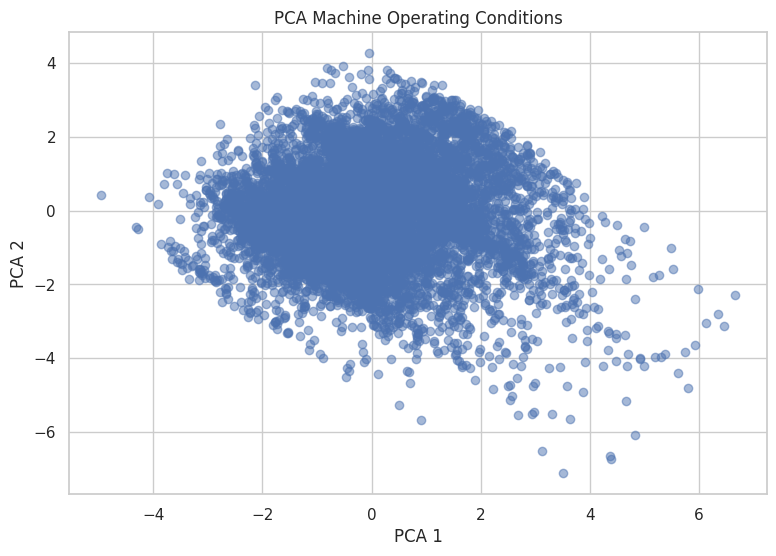

In [32]:
plt.figure(figsize=(9,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.5
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Machine Operating Conditions")

plt.show()

In [33]:
inertia = []
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_unsupervised_scaled
    )

    inertia.append(
        kmeans.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            X_unsupervised_scaled,
            labels
        )
    )

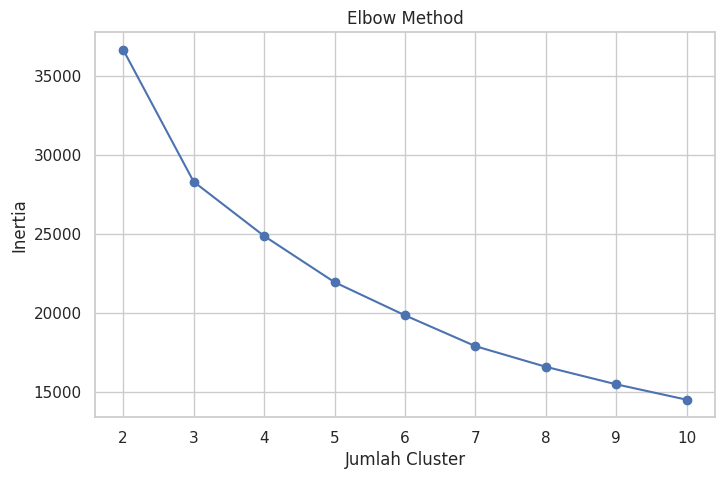

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

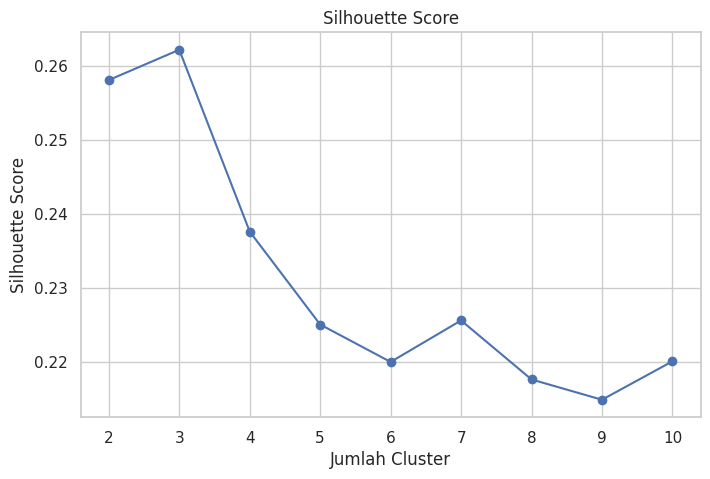

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [36]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    X_unsupervised_scaled
)

print(df["Cluster"].value_counts())

Cluster
1    4017
0    3930
2    2053
Name: count, dtype: int64


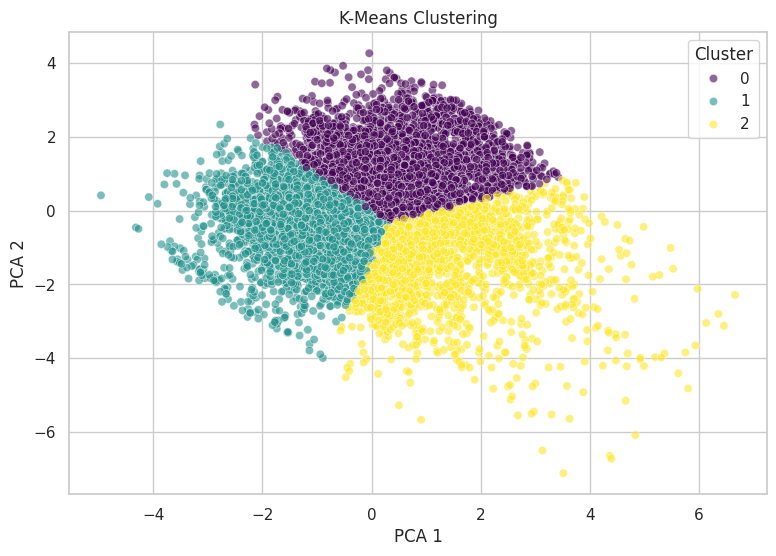

In [37]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["Cluster"],
    palette="viridis",
    alpha=0.6
)

plt.title("K-Means Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [38]:
cluster_analysis = (
    df.groupby("Cluster")
    .agg(
        Total=("Machine failure", "count"),
        Failure=("Machine failure", "sum"),
        Failure_Rate=("Machine failure", "mean"),
        Avg_RPM=("Rotational speed [rpm]", "mean"),
        Avg_Torque=("Torque [Nm]", "mean"),
        Avg_Tool_Wear=("Tool wear [min]", "mean")
    )
)

cluster_analysis["Failure_Rate"] *= 100

display(cluster_analysis)

,Total,Failure,Failure_Rate,Avg_RPM,Avg_Torque,Avg_Tool_Wear
Cluster,,,,,,
0,3930,206,5.241730,1469.807379,43.643333,110.358270
1,4017,87,2.165795,1474.144884,43.264600,104.624844
2,2053,46,2.240623,1797.261568,26.574233,109.850950


In [39]:
rl_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

states = df[rl_features].values

print("Jumlah state:", len(states))
print("Ukuran state:", states.shape)

Jumlah state: 10000
Ukuran state: (10000, 5)


In [40]:
actions = [0, 1]

print("Action 0 = Continue Operation")
print("Action 1 = Maintenance")

Action 0 = Continue Operation
Action 1 = Maintenance


In [41]:
class PredictiveMaintenanceEnv:

    def __init__(self, data):

        self.data = data.reset_index(drop=True)

        self.features = [
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]"
        ]

        self.current_step = 0

    def reset(self):

        self.current_step = 0

        state = self.data.loc[
            self.current_step,
            self.features
        ].values.astype(float)

        return state

    def step(self, action):

        failure = self.data.loc[
            self.current_step,
            "Machine failure"
        ]

        if action == 1:

            reward = -10

        else:

            if failure == 1:
                reward = -100
            else:
                reward = 10

        self.current_step += 1

        done = (
            self.current_step >=
            len(self.data) - 1
        )

        if done:

            next_state = np.zeros(
                len(self.features)
            )

        else:

            next_state = self.data.loc[
                self.current_step,
                self.features
            ].values.astype(float)

        return next_state, reward, done

In [42]:
env = PredictiveMaintenanceEnv(df)

state = env.reset()

print("State awal:")
print(state)

next_state, reward, done = env.step(0)

print("\nNext state:")
print(next_state)

print("\nReward:")
print(reward)

print("\nDone:")
print(done)

State awal:
[ 298.1  308.6 1551.    42.8    0. ]

Next state:
[ 298.2  308.7 1408.    46.3    3. ]

Reward:
10

Done:
False
